# 0. Analyse du biais

On établit d'abord **le constat** : le comité accorde-t-il moins de bourses aux régions éloignées, et cet
écart s'explique-t-il par le dossier des candidats ? On vérifie ensuite si le modèle de production
reproduit ce comportement. Les mesures d'équité formelles sont à la section 1, les variables proxys à la
section 2.

Analyses reprises de `analyse/analyse_donnees.ipynb` (§2 et §4) et de l'ancien audit
(`archives/audit_rapport_old.ipynb`, §2.1).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from analyse.analyse import (entrainer_rf, groupe_region, intervalle_bootstrap, stats_par_groupe,
                             taux_octroi_par, tracer_taux_par_quantile)
from cible import ajuster_modele_decision, score_contrefactuel

pd.set_option('display.width', 200)

NUMERIQUES = ['cote_r_equivalent', 'revenu_familial_estime', 'heures_travail_semaine',
              'distance_domicile_campus_km']
BORNES_R = [0, 26, 27, 28, 29, 30, 32, 45]   # tranches de cote R, plus fines pres du seuil d'octroi

demandes = pd.read_csv('data/donnees_demandes.csv')
demandes['groupe'] = groupe_region(demandes)   # Centre : Montreal, Capitale-Nationale ; Eloignee : les trois autres
groupe = demandes['groupe'].to_numpy()

# Meme decoupage que la baseline et modele_corrige.ipynb : 70/30, stratifie sur la decision du comite.
train, test = train_test_split(demandes, test_size=0.3, random_state=42, stratify=demandes['decision_octroi'])
groupe_te = test['groupe'].to_numpy()

## A. Taux d'octroi du comité

Taux d'octroi historique (`decision_octroi`) par groupe, par région et par programme.

In [2]:
print(taux_octroi_par(demandes, 'groupe').round(3))
print()
print(taux_octroi_par(demandes, 'region_administrative').round(3))
print()
print(pd.crosstab(demandes['programme_etudes'], demandes['groupe'], values=demandes['decision_octroi'],
                  aggfunc='mean').assign(ecart=lambda t: t['Centre'] - t['Eloignee']).round(3))

          effectif  taux_octroi
groupe                         
Centre        6000        0.484
Eloignee      4000        0.273

                               effectif  taux_octroi
region_administrative                               
Bas-Saint-Laurent                  1293        0.269
Capitale-Nationale                 1999        0.484
Cote-Nord                          1178        0.263
Gaspesie-Iles-de-la-Madeleine      1529        0.284
Montreal                           4001        0.483

groupe             Centre  Eloignee  ecart
programme_etudes                          
Arts et lettres     0.457     0.261  0.196
Genie               0.499     0.291  0.208
Sante               0.486     0.264  0.222
Sciences            0.485     0.288  0.198
Sciences sociales   0.481     0.263  0.218


**Lecture.**
- Le comité accorde la bourse à **48.4 %** des candidats du Centre contre **27.3 %** des candidats éloignés :
  un écart de **21 points**.
- L'écart est **uniforme** : les trois régions éloignées sont entre 26 % et 28 %, les deux centres à 48 %, et
  l'écart vaut 20 à 22 points dans chacun des cinq programmes. Il ne vient donc ni d'une région ni d'un
  programme particulier : c'est la signature d'une pénalité liée à l'appartenance au groupe éloigné.

## B. À mérite scolaire égal

Un écart de taux d'octroi n'est pas en soi un biais : il pourrait refléter des dossiers plus faibles. On
compare donc la cote R des deux groupes, puis le taux d'octroi à cote R égale.

                            moyenne  ecart_type  mediane
cote_r_equivalent Centre      27.99        2.99    27.98
                  Eloignee    27.33        2.98    27.29

Taux d'octroi du comite par tranche de cote R :
groupe             Centre  Eloignee  ecart
cote_r_equivalent                         
(0, 26]             0.020     0.005  0.016
(26, 27]            0.161     0.038  0.123
(27, 28]            0.316     0.100  0.216
(28, 29]            0.593     0.256  0.336
(29, 30]            0.849     0.568  0.281
(30, 32]            0.958     0.831  0.128
(32, 45]            0.998     0.986  0.012


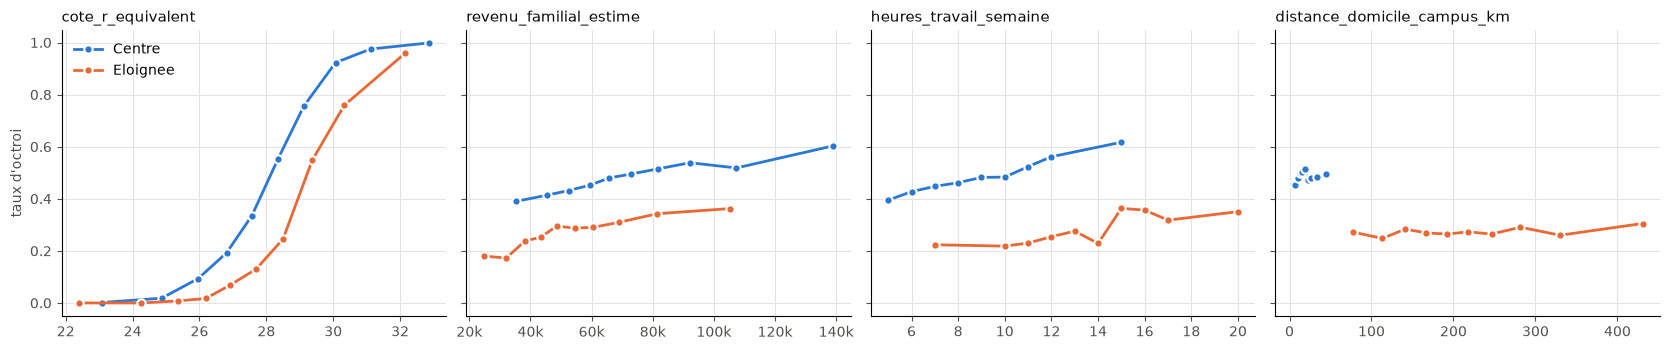

In [3]:
print(stats_par_groupe(demandes, ['cote_r_equivalent'])[['moyenne', 'ecart_type', 'mediane']].round(2))
print()
print('Taux d\'octroi du comite par tranche de cote R :')
tranche_r = pd.cut(demandes['cote_r_equivalent'], BORNES_R)
print(pd.crosstab(tranche_r, demandes['groupe'], values=demandes['decision_octroi'], aggfunc='mean')
      .assign(ecart=lambda t: t['Centre'] - t['Eloignee']).round(3))
tracer_taux_par_quantile(demandes, NUMERIQUES)

**Lecture.**
- La cote R est presque la même dans les deux groupes (28.0 contre 27.3, soit 0.2 écart-type) : le mérite
  scolaire n'explique pas un écart de 21 points.
- **À cote R égale**, l'écart est massif près du seuil d'octroi : entre 28 et 29, le comité accorde la bourse
  à 59 % des candidats du Centre contre 26 % des candidats éloignés ; entre 29 et 30, à 85 % contre 57 %. Loin
  du seuil (cote R de moins de 26 ou de 32 et plus), les deux groupes sont traités de la même façon : la
  pénalité touche les dossiers « limites ».
- Sur le premier graphique, la courbe des régions éloignées est décalée d'environ un point de cote R vers la
  droite : un candidat éloigné doit avoir une meilleure cote pour le même taux d'octroi.
- **Dans chaque groupe**, le taux d'octroi augmente aussi avec le revenu et avec les heures travaillées : le
  comité utilise d'autres critères que la cote R. Il faut donc en tenir compte (section C).

## C. Décomposition de l'écart

Pour tenir compte de tous les critères du comité à la fois, on le modélise par une régression logistique
qui inclut un indicateur de région (`cible.ajuster_modele_decision`, AUC de 0.95 contre `decision_octroi`).
On calcule ensuite, pour chaque candidat éloigné, sa probabilité d'octroi **s'il avait été traité comme un
candidat du Centre** : même dossier, indicateur de région mis à 0 (un *contrefactuel*). L'écart se décompose
en deux parts :
- **part due au profil** = taux du Centre - taux contrefactuel des éloignés. Elle vient des différences de
  dossier (cote R, revenu, heures...), valorisées comme le fait le comité ;
- **pénalité régionale** = taux contrefactuel des éloignés - leur taux observé. C'est la part qu'aucune
  caractéristique du dossier n'explique.

Les intervalles de confiance à 95 % sont obtenus par bootstrap stratifié par groupe (200 tirages) ; le modèle
est réajusté à chaque tirage.

In [5]:
def decomposer_ecart(indices):
    """Ecart d'octroi du comite (Centre - Eloignee), decompose en profil et penalite regionale."""
    s, g = demandes.iloc[indices], groupe[indices]
    modele = ajuster_modele_decision(s)
    centre = s.loc[g == 'Centre', 'decision_octroi'].mean()
    eloignee = s.loc[g == 'Eloignee', 'decision_octroi'].mean()
    # Taux d'octroi des candidats eloignes s'ils avaient ete traites comme ceux du Centre.
    eloignee_cf = score_contrefactuel(modele, s[g == 'Eloignee'], retrait=1).mean()
    return {'ecart_total': centre - eloignee,
            'part_profil': centre - eloignee_cf,
            'part_penalite_regionale': eloignee_cf - eloignee}


decomposition = intervalle_bootstrap(decomposer_ecart, np.arange(len(demandes)), strates=groupe, n=200)
print(decomposition.round(3))

                         estimation    bas   haut
ecart_total                   0.211  0.193  0.230
part_profil                   0.030  0.004  0.061
part_penalite_regionale       0.180  0.153  0.205


**Lecture.**
- Sur les **21 points** d'écart (IC 95 % : 19 à 23), **18 points** (IC : 15 à 21) restent inexpliqués à profil
  égal : c'est la **pénalité régionale directe**. Un candidat éloigné a 18 points de moins de chances
  d'obtenir la bourse qu'un candidat du Centre au dossier identique.
- Seuls **3 points** (IC : 0.4 à 6) s'expliquent par les différences de profil, surtout le revenu, plus élevé
  au Centre et valorisé par le comité.
- Limite : la distance des deux groupes ne se chevauche presque pas (seuls 21 % des dossiers éloignés sont
  dans l'étendue de distance du Centre, `analyse_donnees.ipynb` §2) ; le contrefactuel repose donc en partie
  sur l'extrapolation du modèle logistique.

## D. Le modèle de production reproduit le biais

Le modèle de production (forêt aléatoire de `baseline_model.ipynb`) est entraîné à reproduire
`decision_octroi`. On compare ses taux d'octroi à ceux du comité sur le jeu de test.

In [6]:
rf, X_te_rf, decisions_rf = entrainer_rf(train, test)
y_comite = test['decision_octroi'].to_numpy()

taux = pd.DataFrame({'comite': pd.Series(y_comite).groupby(groupe_te).mean(),
                     'RF de production': pd.Series(decisions_rf).groupby(groupe_te).mean()}).T
taux['ecart'] = taux['Centre'] - taux['Eloignee']
print(taux.round(3))
print(f'\nAccord du RF avec le comite : {(decisions_rf == y_comite).mean():.1%}')

                  Centre  Eloignee  ecart
comite             0.484     0.277  0.207
RF de production   0.459     0.271  0.188

Accord du RF avec le comite : 88.1%


**Lecture.** Le RF reproduit fidèlement le comité (88 % d'accord) : il accorde la bourse à 46 % des candidats
du Centre contre 27 % des candidats éloignés, un écart de 19 points, comparable aux 21 points du comité sur le
même jeu de test. Entraîné sur une étiquette biaisée, le modèle apprend la pénalité régionale avec le reste.
Toute évaluation qui le compare à `decision_octroi` ne peut donc pas détecter ce biais : c'est pourquoi la
section 1 mesure l'équité contre une référence de mérite.

# 1. Mesures d'équités

## A. Parité démographique
L'évaluation du la parité entre les 2 populations peut se faire par la comparaison des taux d'admission. 

In [7]:
#TODO: évaluation du taux d'octroi pour les données historiques et pour le nouveau modèle pour chaque groupe de population

## B. Égalité des chances
Taux d'acceptation au sein des élèves qualifiés. 

In [8]:
#TODO: évaluation du taux d'octroi, en mesurant la qualification comme la cote R seulement pour chaque groupe de la population.

# 2. Variables proxy

In [9]:
# TODO: tableau des corrélations

In [10]:
# TODO: FPGrowth